# HI Survey --- Science Products

Load reduced data from `02_scan_load.ipynb` and produce report-ready
figures: reference spectrum, position-velocity diagrams, integrated
intensity and peak velocity maps, and channel maps.

In [1]:
import sys; sys.path.insert(0, '..')

import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting
from ugradiolab.plotting import (SS_FINE, LABEL_SIZE, TICK_SIZE,
                                  EMPHASIS_SIZE, LW_FINE, LW_STANDARD,
                                  ALPHA_STANDARD, ALPHA_LIGHT, ALPHA_FAINT,
                                  NEUTRAL_COLOR, GRID_STYLE)
from plotters import (plot_hi_spectrum, plot_survey_mollweide,
                      plot_heatmap, add_never_observable_overlay)

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

HI_REST_MHZ = 1420.405
C_KMS = 299792.458
MOLL_CENTER_L = 120.0

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load reduced data

In [2]:
REDUCED_PATH = Path('../reduced_survey.npz')

with np.load(REDUCED_PATH) as f:
    cell_keys = f['cell_keys']        # (N, 2) int: (l, b)
    R_stack = f['R_stack']            # (N, n_ch) float: R(v_LSR)
    v_lsr = f['v_lsr']               # (n_ch,) float
    dv_kms = float(f['dv_kms'])
    n_pairs = f['n_pairs']
    W_flag = f['W_flag']
    peak_v_flag = f['peak_v_flag']
    W = f['W']
    peak_v = f['peak_v']
    snr = f['snr']

gl = cell_keys[:, 0].astype(float)
gb = cell_keys[:, 1].astype(float)
any_flag = W_flag | peak_v_flag
clean = ~any_flag

print(f'Loaded {len(cell_keys)} cells ({clean.sum()} clean, {any_flag.sum()} flagged)')
print(f'Velocity: [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s LSR, dv={dv_kms:.3f} km/s')

Loaded 1618 cells (1597 clean, 21 flagged)
Velocity: [-145, 76] km/s LSR, dv=0.528 km/s


## 2. Reference spectrum at (l=120, b=0)

Required by the lab manual for cross-group comparison.

n_pairs = 4, SNR = 14.5


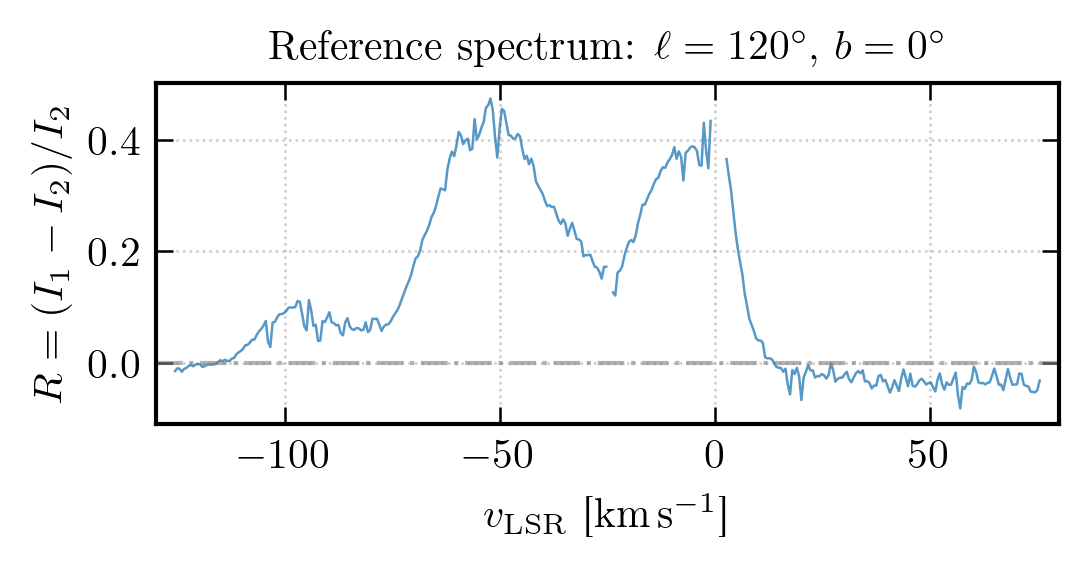

In [3]:
ref_idx = np.where((cell_keys[:, 0] == 120) & (cell_keys[:, 1] == 0))[0]

if len(ref_idx) == 0:
    print('WARNING: (l=120, b=0) not found in reduced data')
else:
    i = ref_idx[0]
    R_ref = R_stack[i]
    ax = plot_hi_spectrum(
        v_lsr, R_ref,
        title=r'Reference spectrum: $\ell=120^\circ$, $b=0^\circ$',
        ylabel=r'$R = (I_1 - I_2) / I_2$',
        xlabel=r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]',
        color='C0', ax=None,
    )
    ax.set_xlim(-130, 80)
    print(f'n_pairs = {n_pairs[i]}, SNR = {snr[i]:.1f}')
    plt.show()

## 3. Position-velocity diagrams

Longitude-velocity (l-v) cuts at selected latitudes.

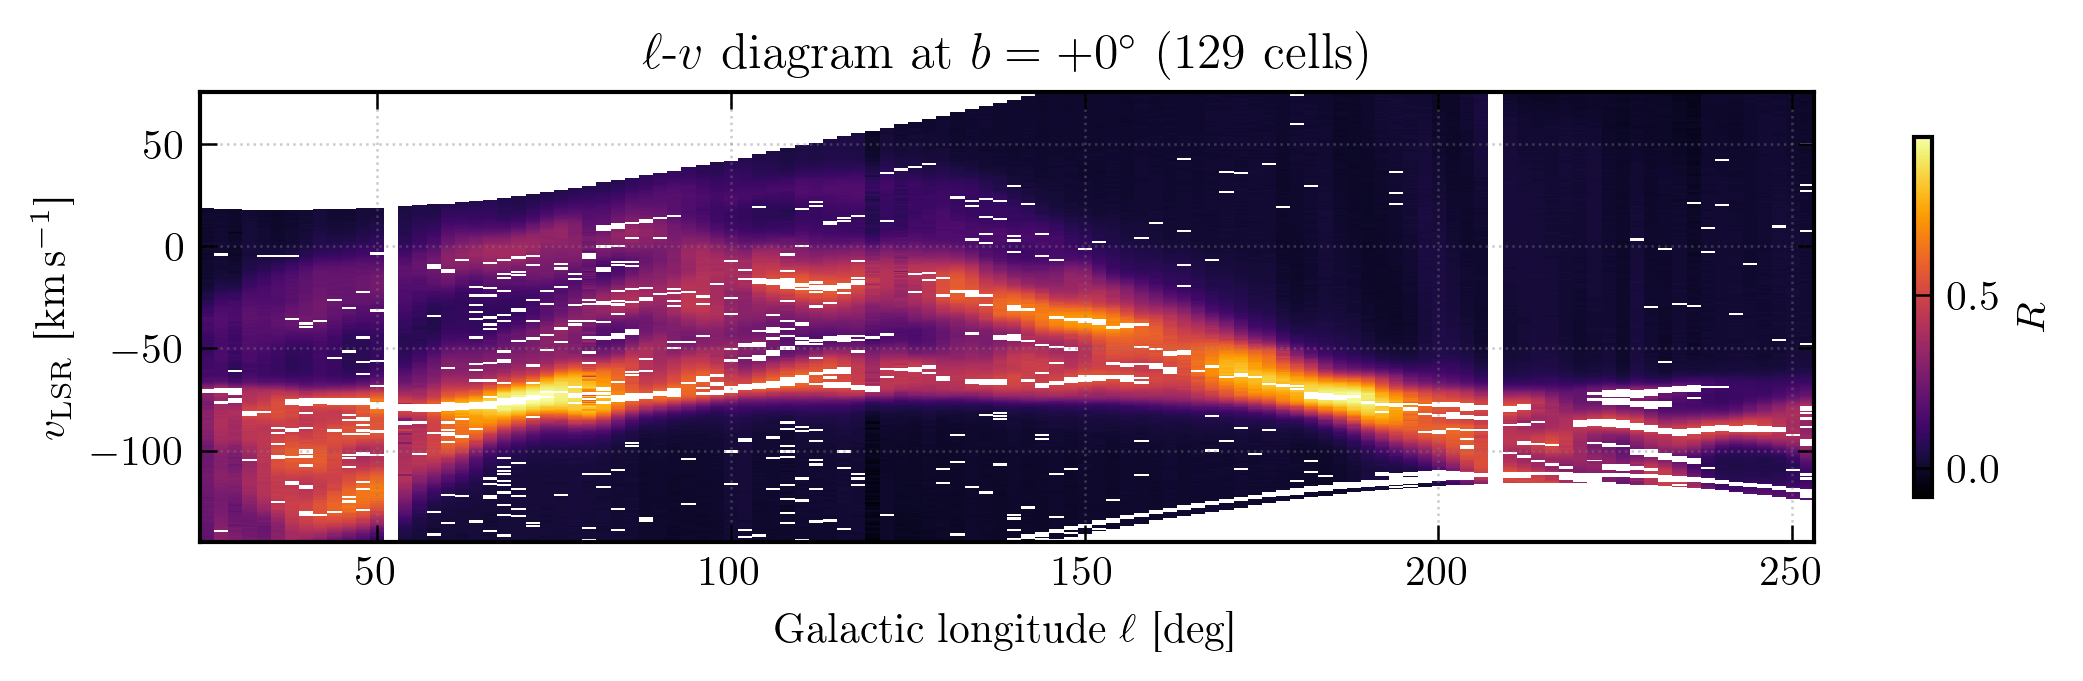

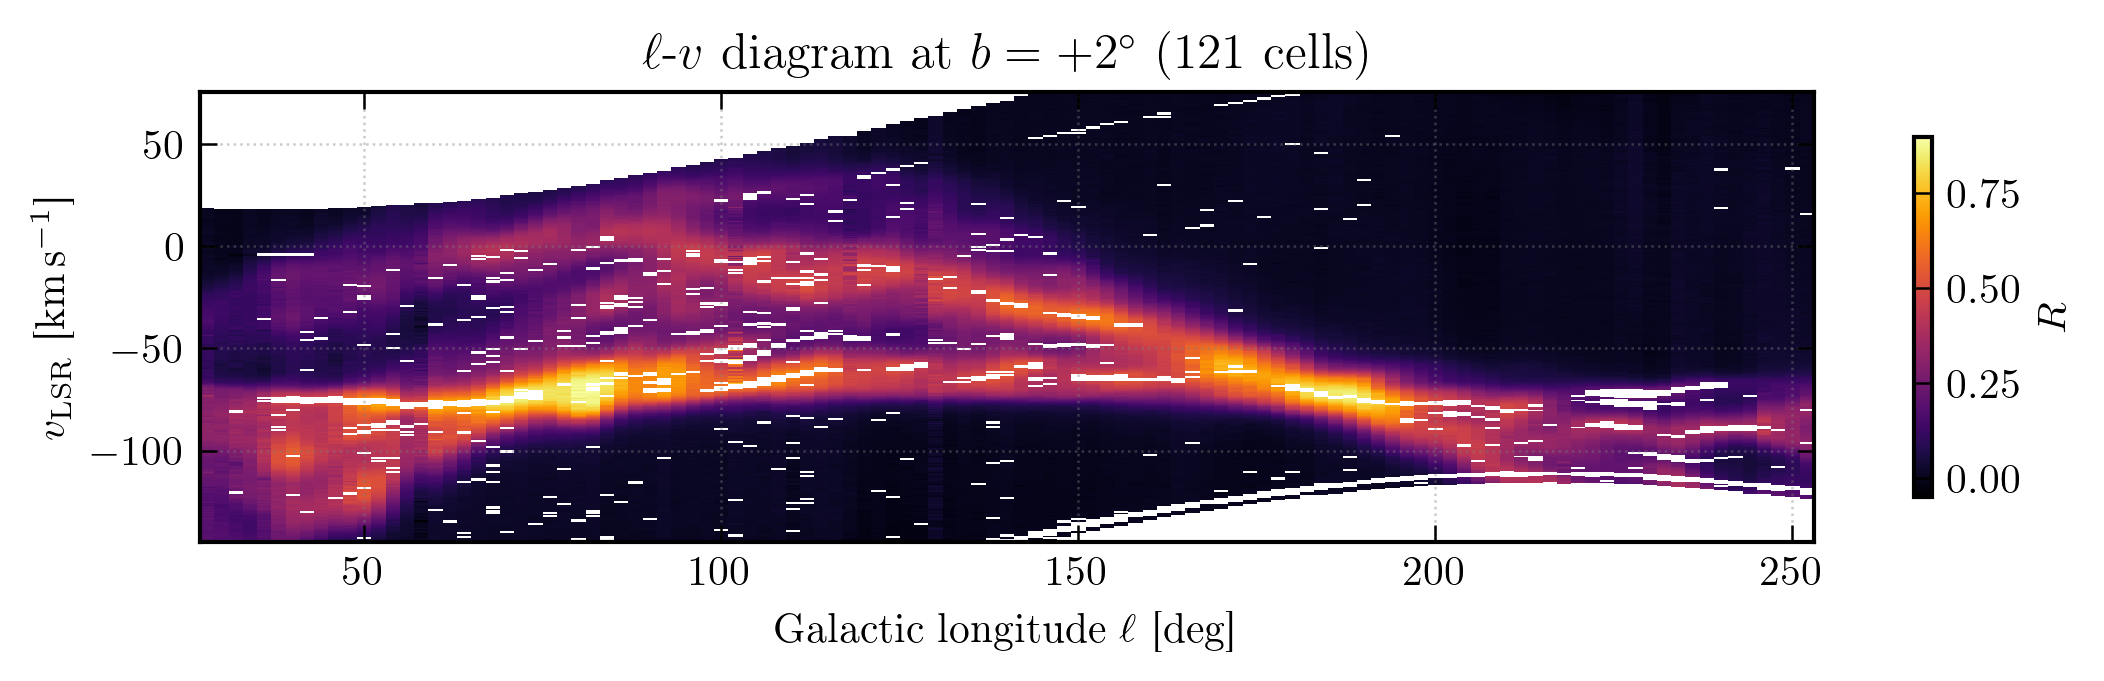

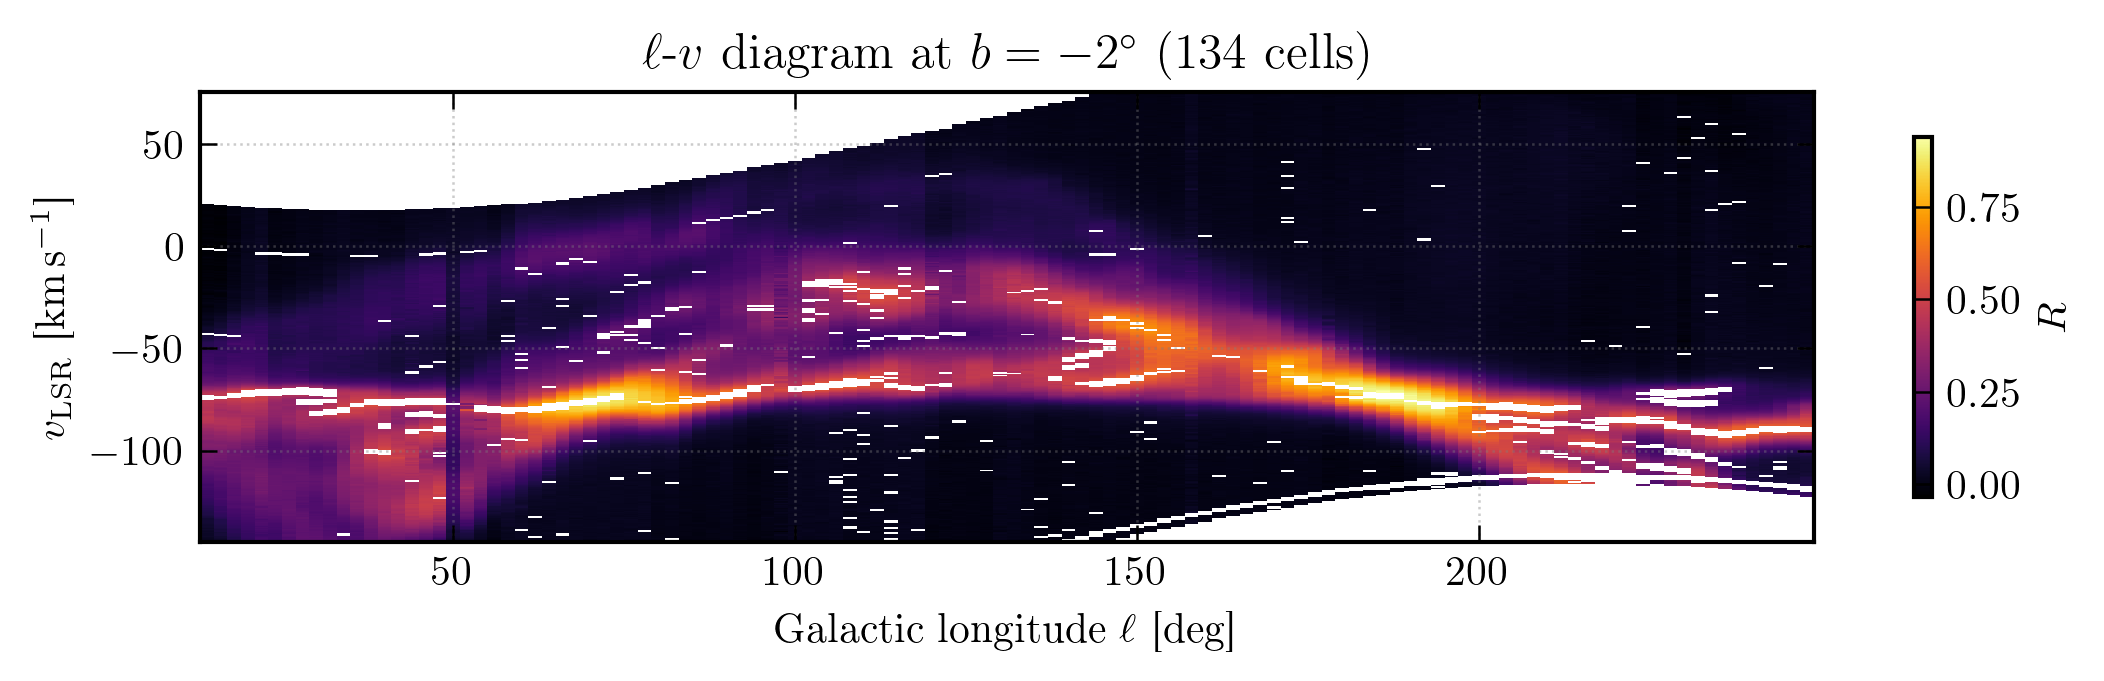

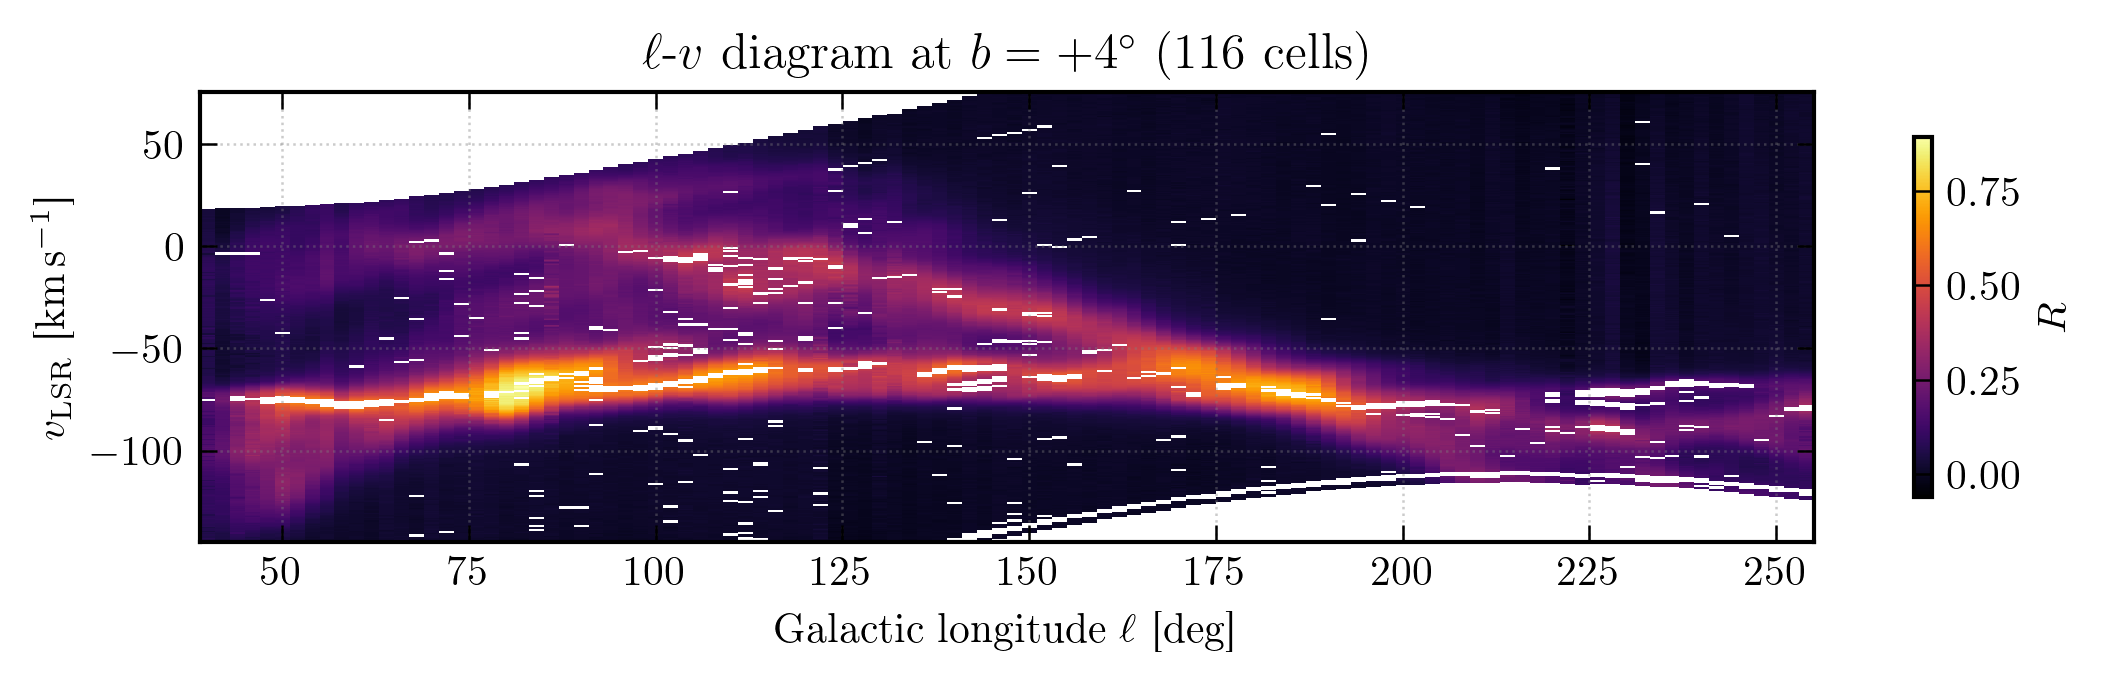

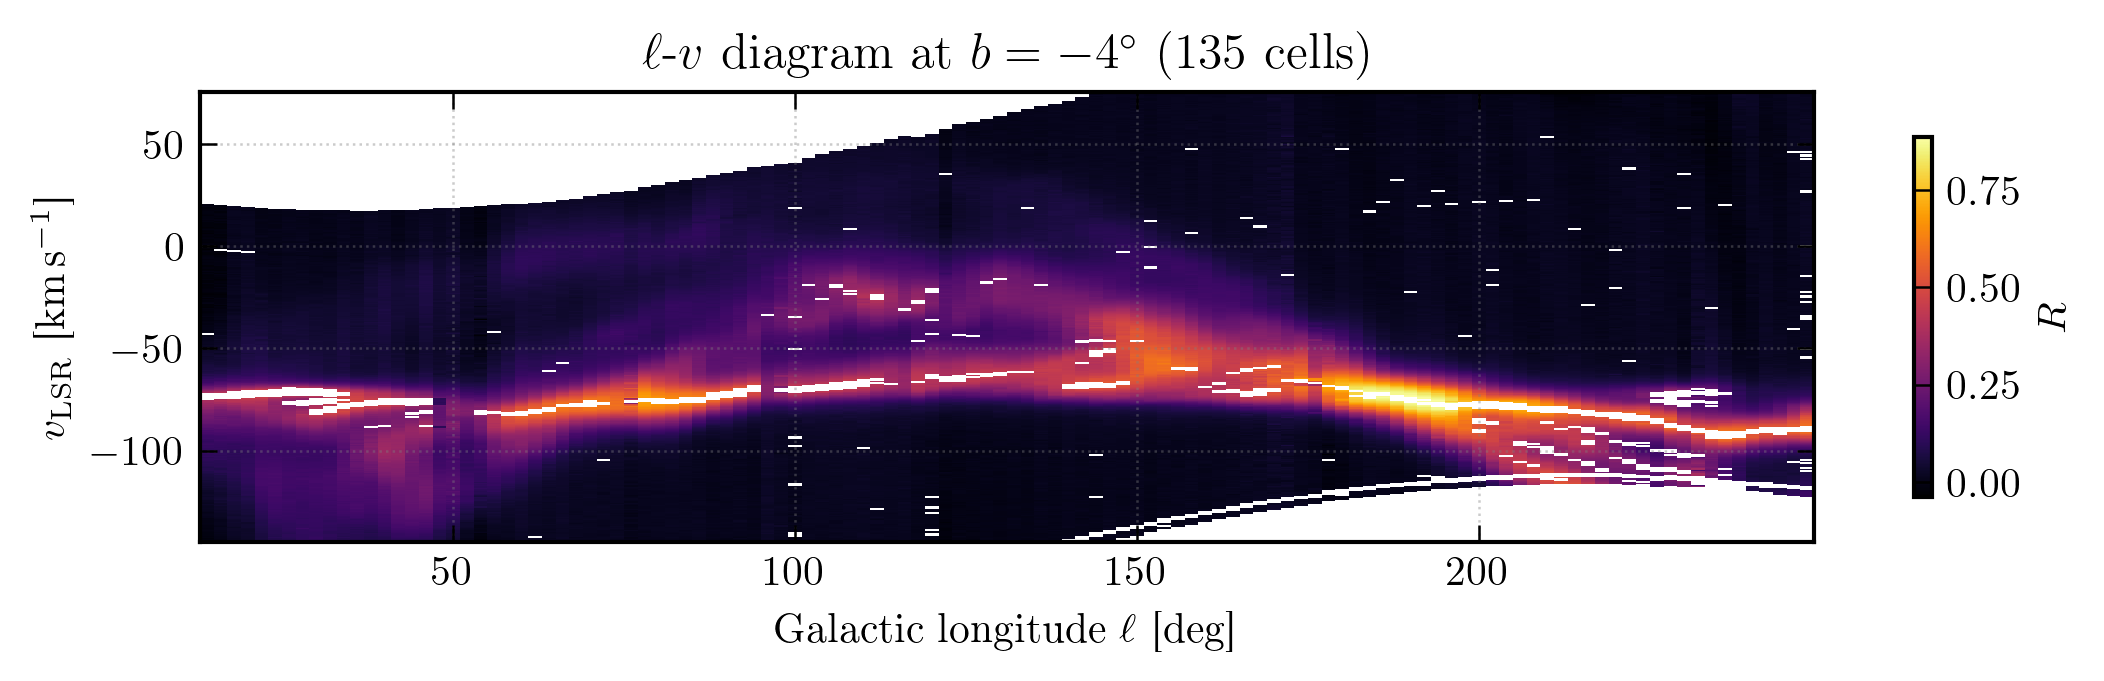

In [4]:
b_cuts = [0, 2, -2, 4, -4]

for b_cut in b_cuts:
    sel = np.where((cell_keys[:, 1] == b_cut) & clean)[0]
    if len(sel) < 3:
        continue

    # Sort by longitude
    order = np.argsort(cell_keys[sel, 0])
    sel = sel[order]
    l_vals = cell_keys[sel, 0]

    # Build l-v image
    l_unique = np.arange(l_vals.min(), l_vals.max() + 1, 2)
    lv_img = np.full((len(v_lsr), len(l_unique)), np.nan)
    for j, idx in enumerate(sel):
        li = np.searchsorted(l_unique, cell_keys[idx, 0])
        if 0 <= li < len(l_unique):
            lv_img[:, li] = R_stack[idx]

    fig, ax = plotting.textwidth_figure(5)
    im = ax.imshow(
        lv_img, origin='lower', aspect='auto',
        extent=[l_unique[0] - 1, l_unique[-1] + 1, v_lsr[-1], v_lsr[0]],
        cmap='inferno', interpolation='nearest',
    )
    ax.set_xlabel(r'Galactic longitude $\ell$ [deg]', fontsize=LABEL_SIZE)
    ax.set_ylabel(r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]', fontsize=LABEL_SIZE)
    ax.set_title(rf'$\ell$-$v$ diagram at $b = {b_cut:+d}^\circ$ '
                 rf'({len(sel)} cells)', fontsize=EMPHASIS_SIZE)
    plt.colorbar(im, ax=ax, label=r'$R$', shrink=0.8)
    plt.show()

## 4. Latitude-velocity slices

b-v cuts at selected longitudes.

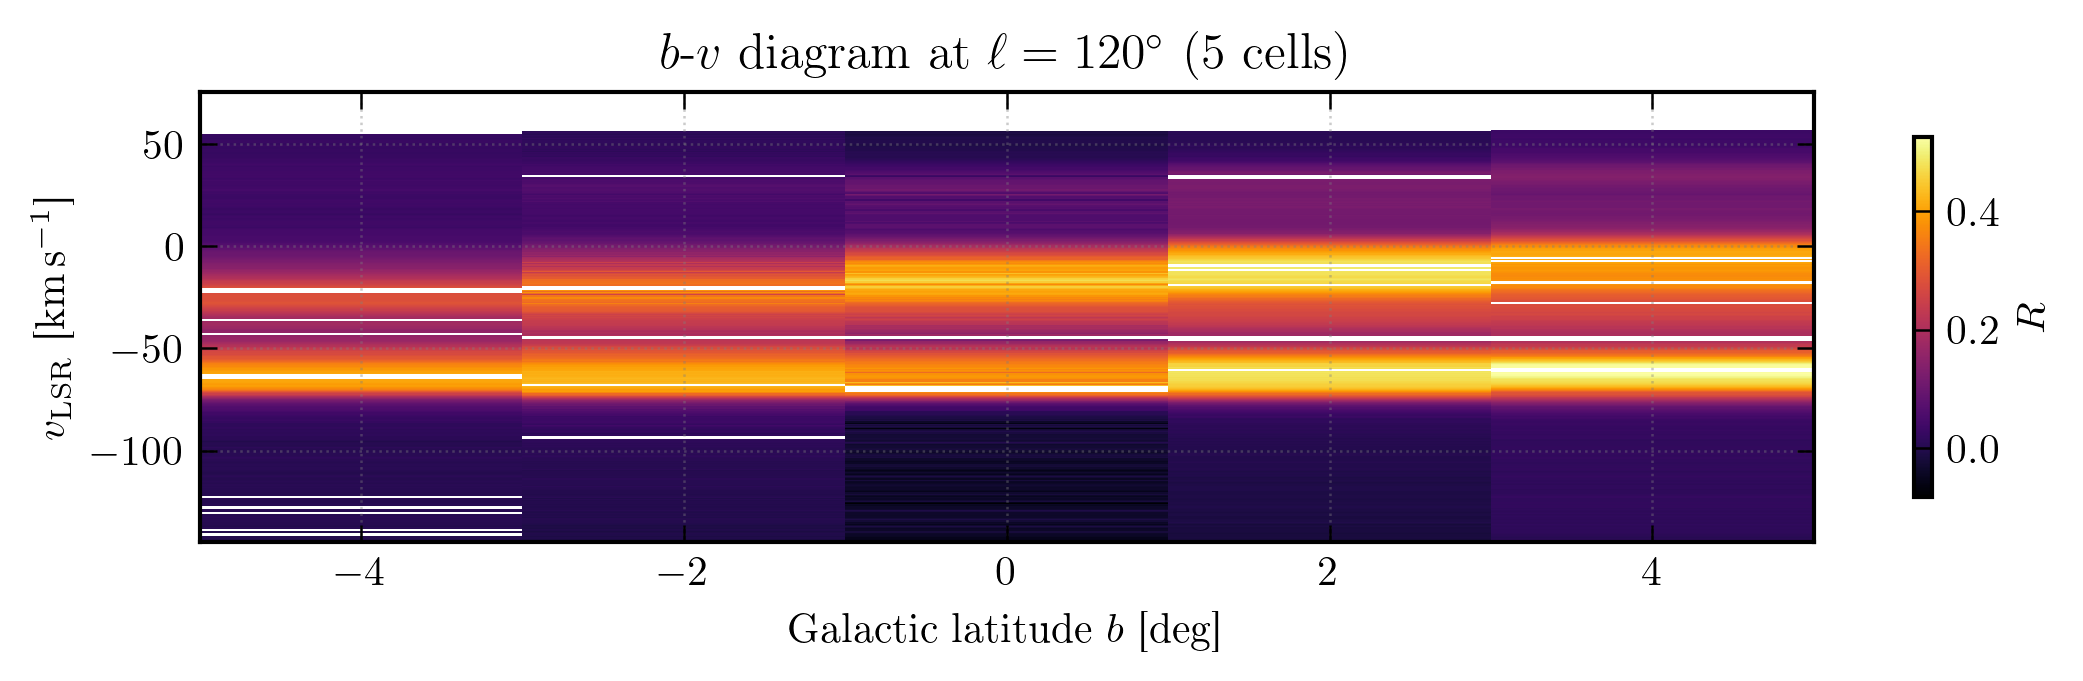

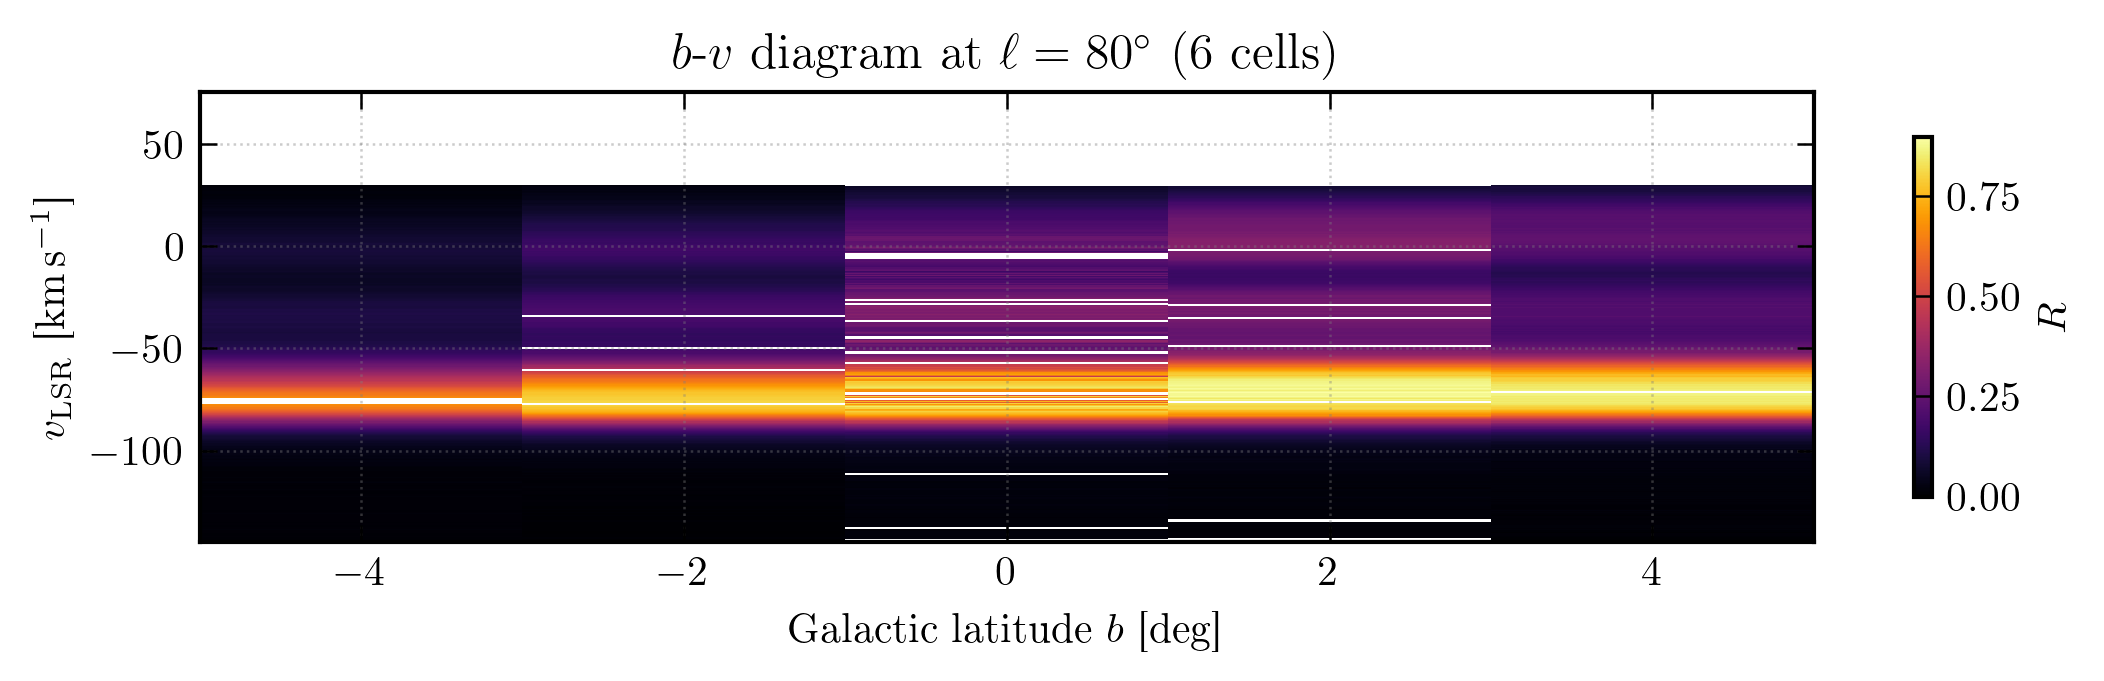

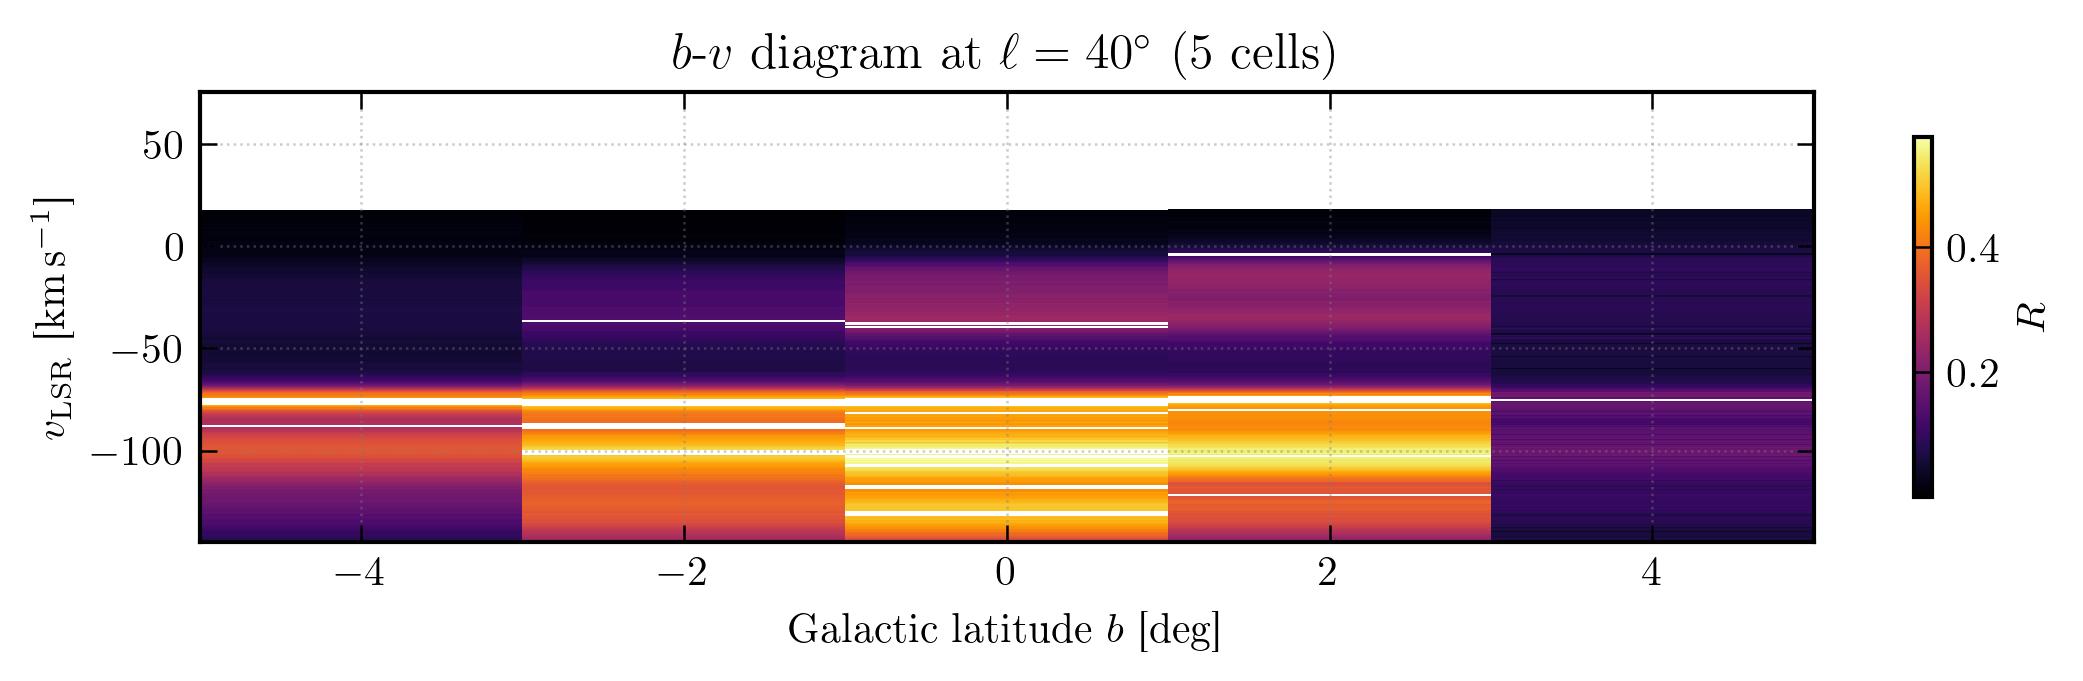

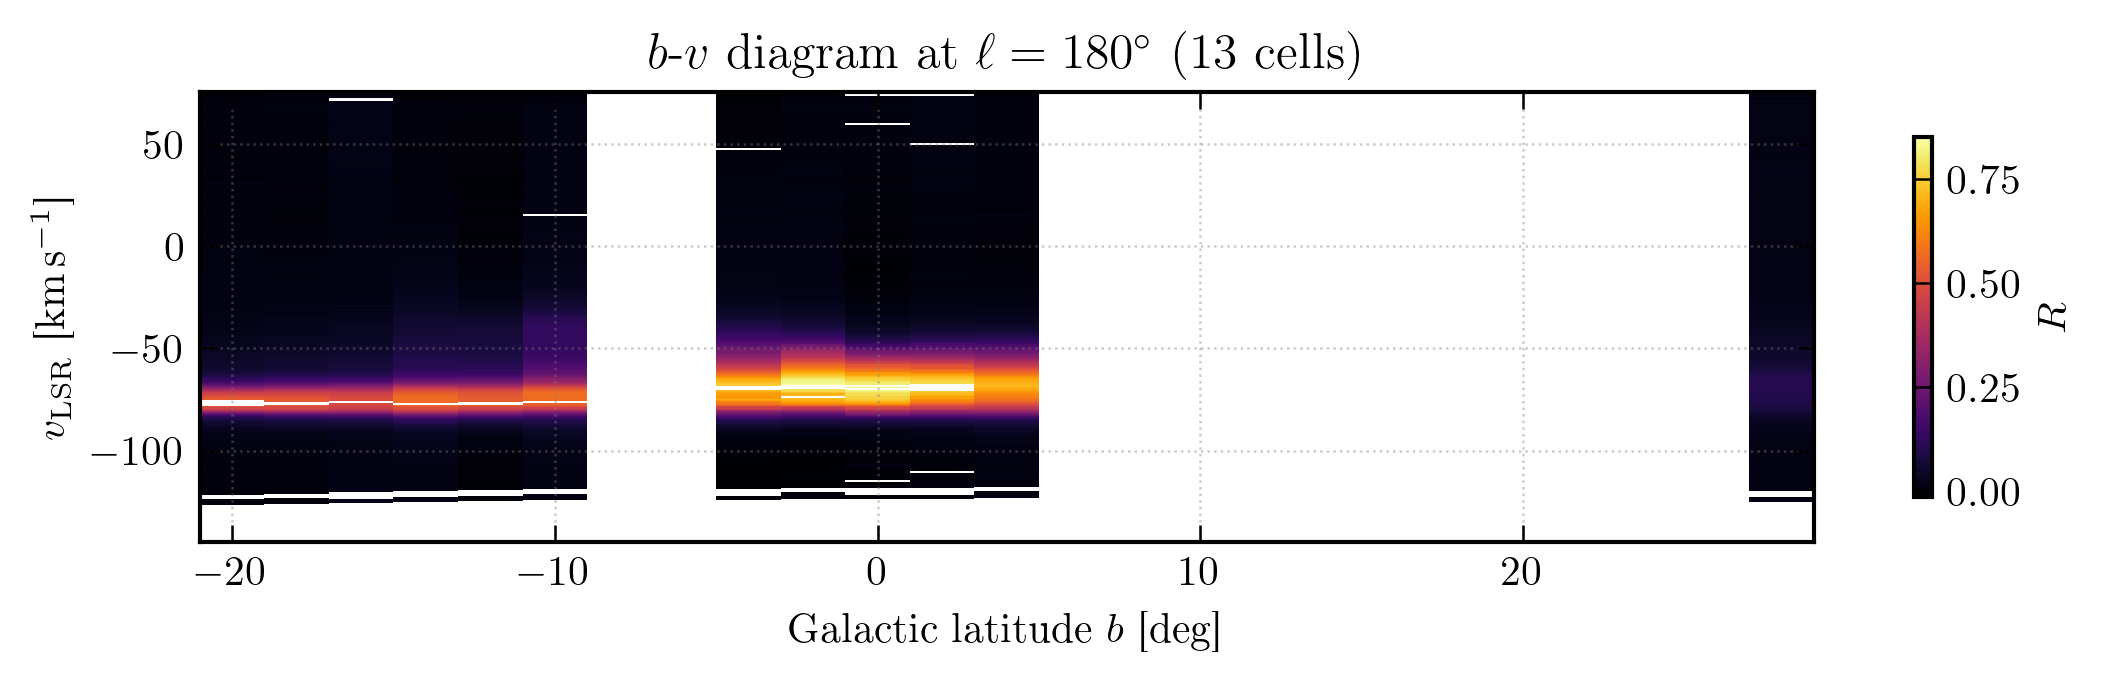

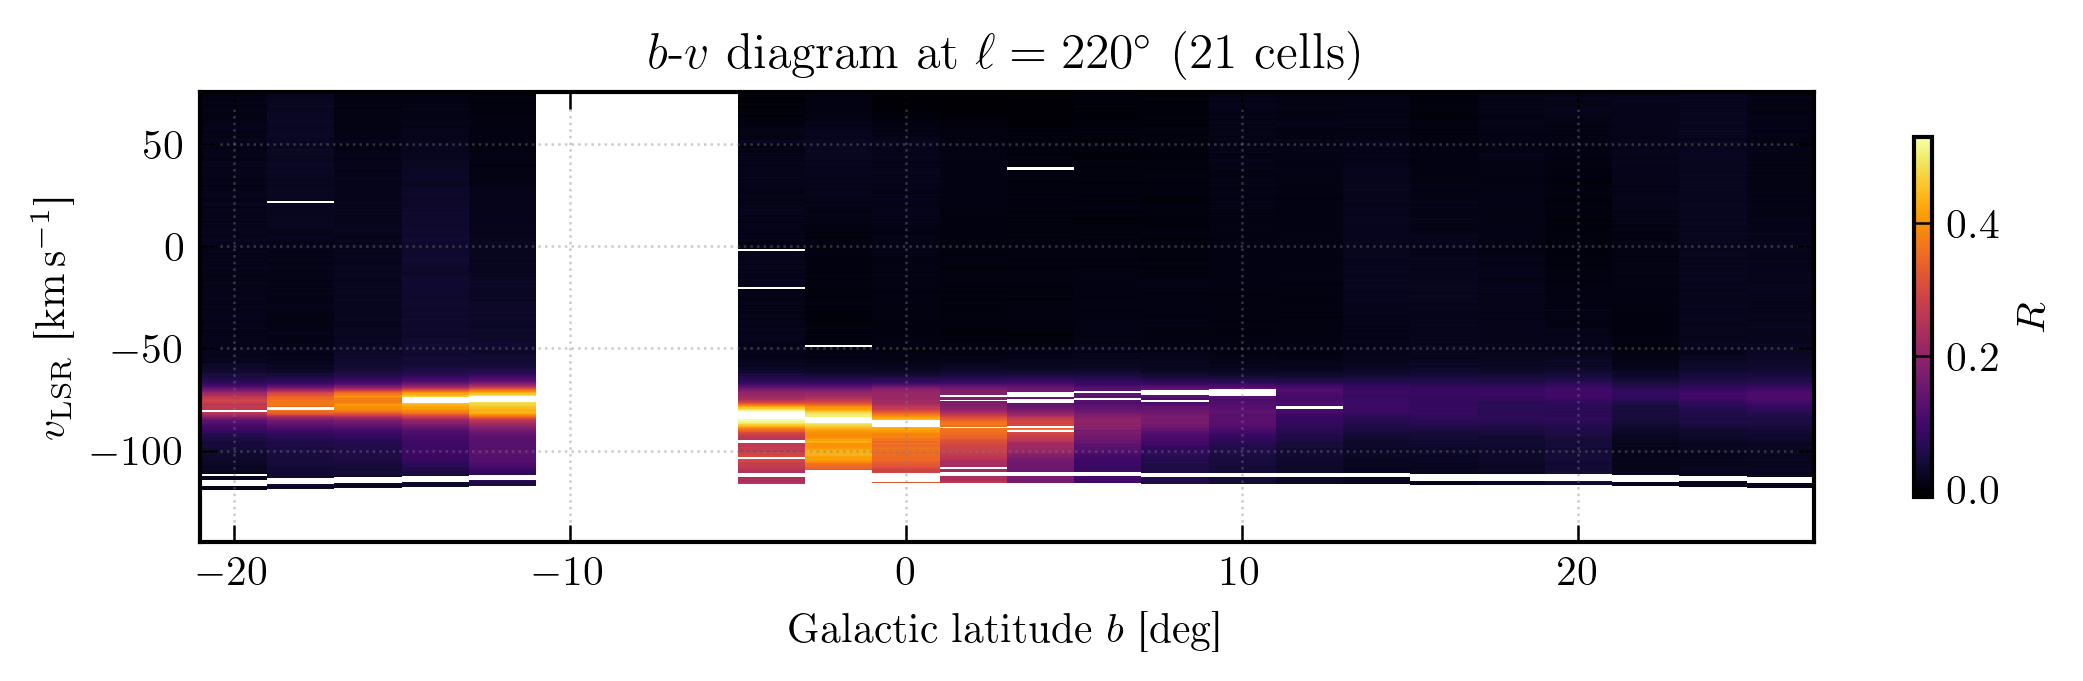

In [5]:
l_cuts = [120, 80, 40, 180, 220]

for l_cut in l_cuts:
    sel = np.where((cell_keys[:, 0] == l_cut) & clean)[0]
    if len(sel) < 3:
        continue

    order = np.argsort(cell_keys[sel, 1])
    sel = sel[order]
    b_vals = cell_keys[sel, 1]

    b_unique = np.arange(b_vals.min(), b_vals.max() + 1, 2)
    bv_img = np.full((len(v_lsr), len(b_unique)), np.nan)
    for j, idx in enumerate(sel):
        bi = np.searchsorted(b_unique, cell_keys[idx, 1])
        if 0 <= bi < len(b_unique):
            bv_img[:, bi] = R_stack[idx]

    fig, ax = plotting.textwidth_figure(5)
    im = ax.imshow(
        bv_img, origin='lower', aspect='auto',
        extent=[b_unique[0] - 1, b_unique[-1] + 1, v_lsr[-1], v_lsr[0]],
        cmap='inferno', interpolation='nearest',
    )
    ax.set_xlabel(r'Galactic latitude $b$ [deg]', fontsize=LABEL_SIZE)
    ax.set_ylabel(r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]', fontsize=LABEL_SIZE)
    ax.set_title(rf'$b$-$v$ diagram at $\ell = {l_cut}^\circ$ '
                 rf'({len(sel)} cells)', fontsize=EMPHASIS_SIZE)
    plt.colorbar(im, ax=ax, label=r'$R$', shrink=0.8)
    plt.show()

## 5. Integrated intensity map W(l, b)

Mollweide projection of velocity-integrated R.

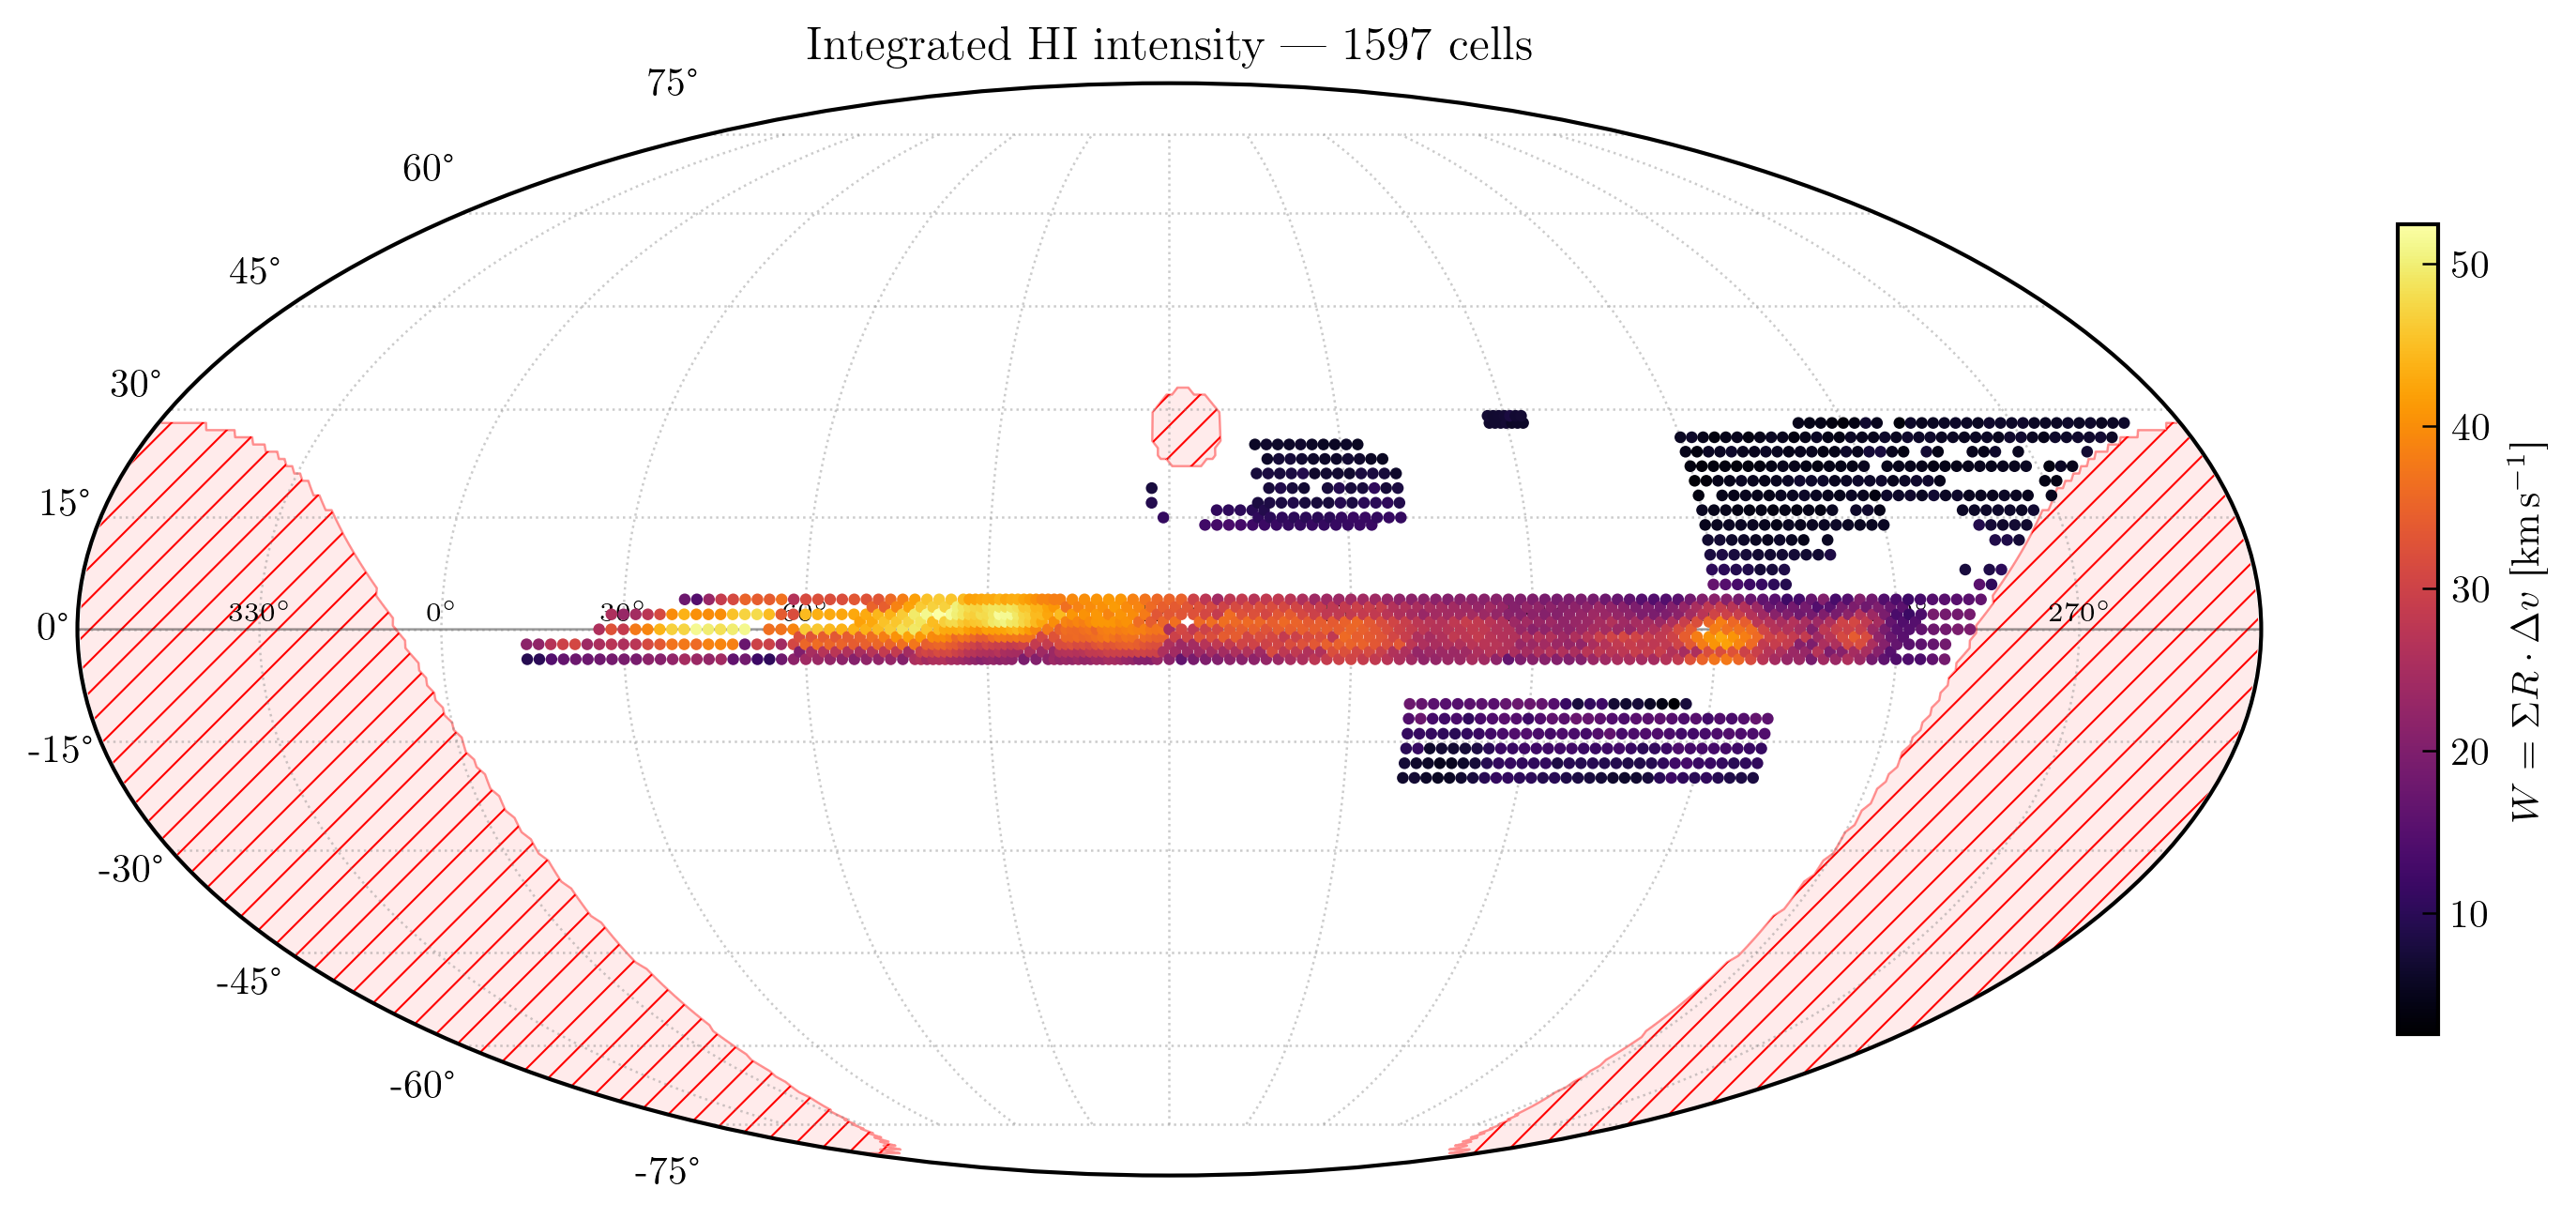

In [6]:
fig, ax = plot_survey_mollweide(
    gl[clean], gb[clean], W[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]',
    cmap='inferno',
    marker_size=SS_FINE,
    title=f'Integrated HI intensity --- {clean.sum()} cells',
)
plt.show()

## 6. Peak velocity map v_peak(l, b)

Mollweide projection of peak LSR velocity.

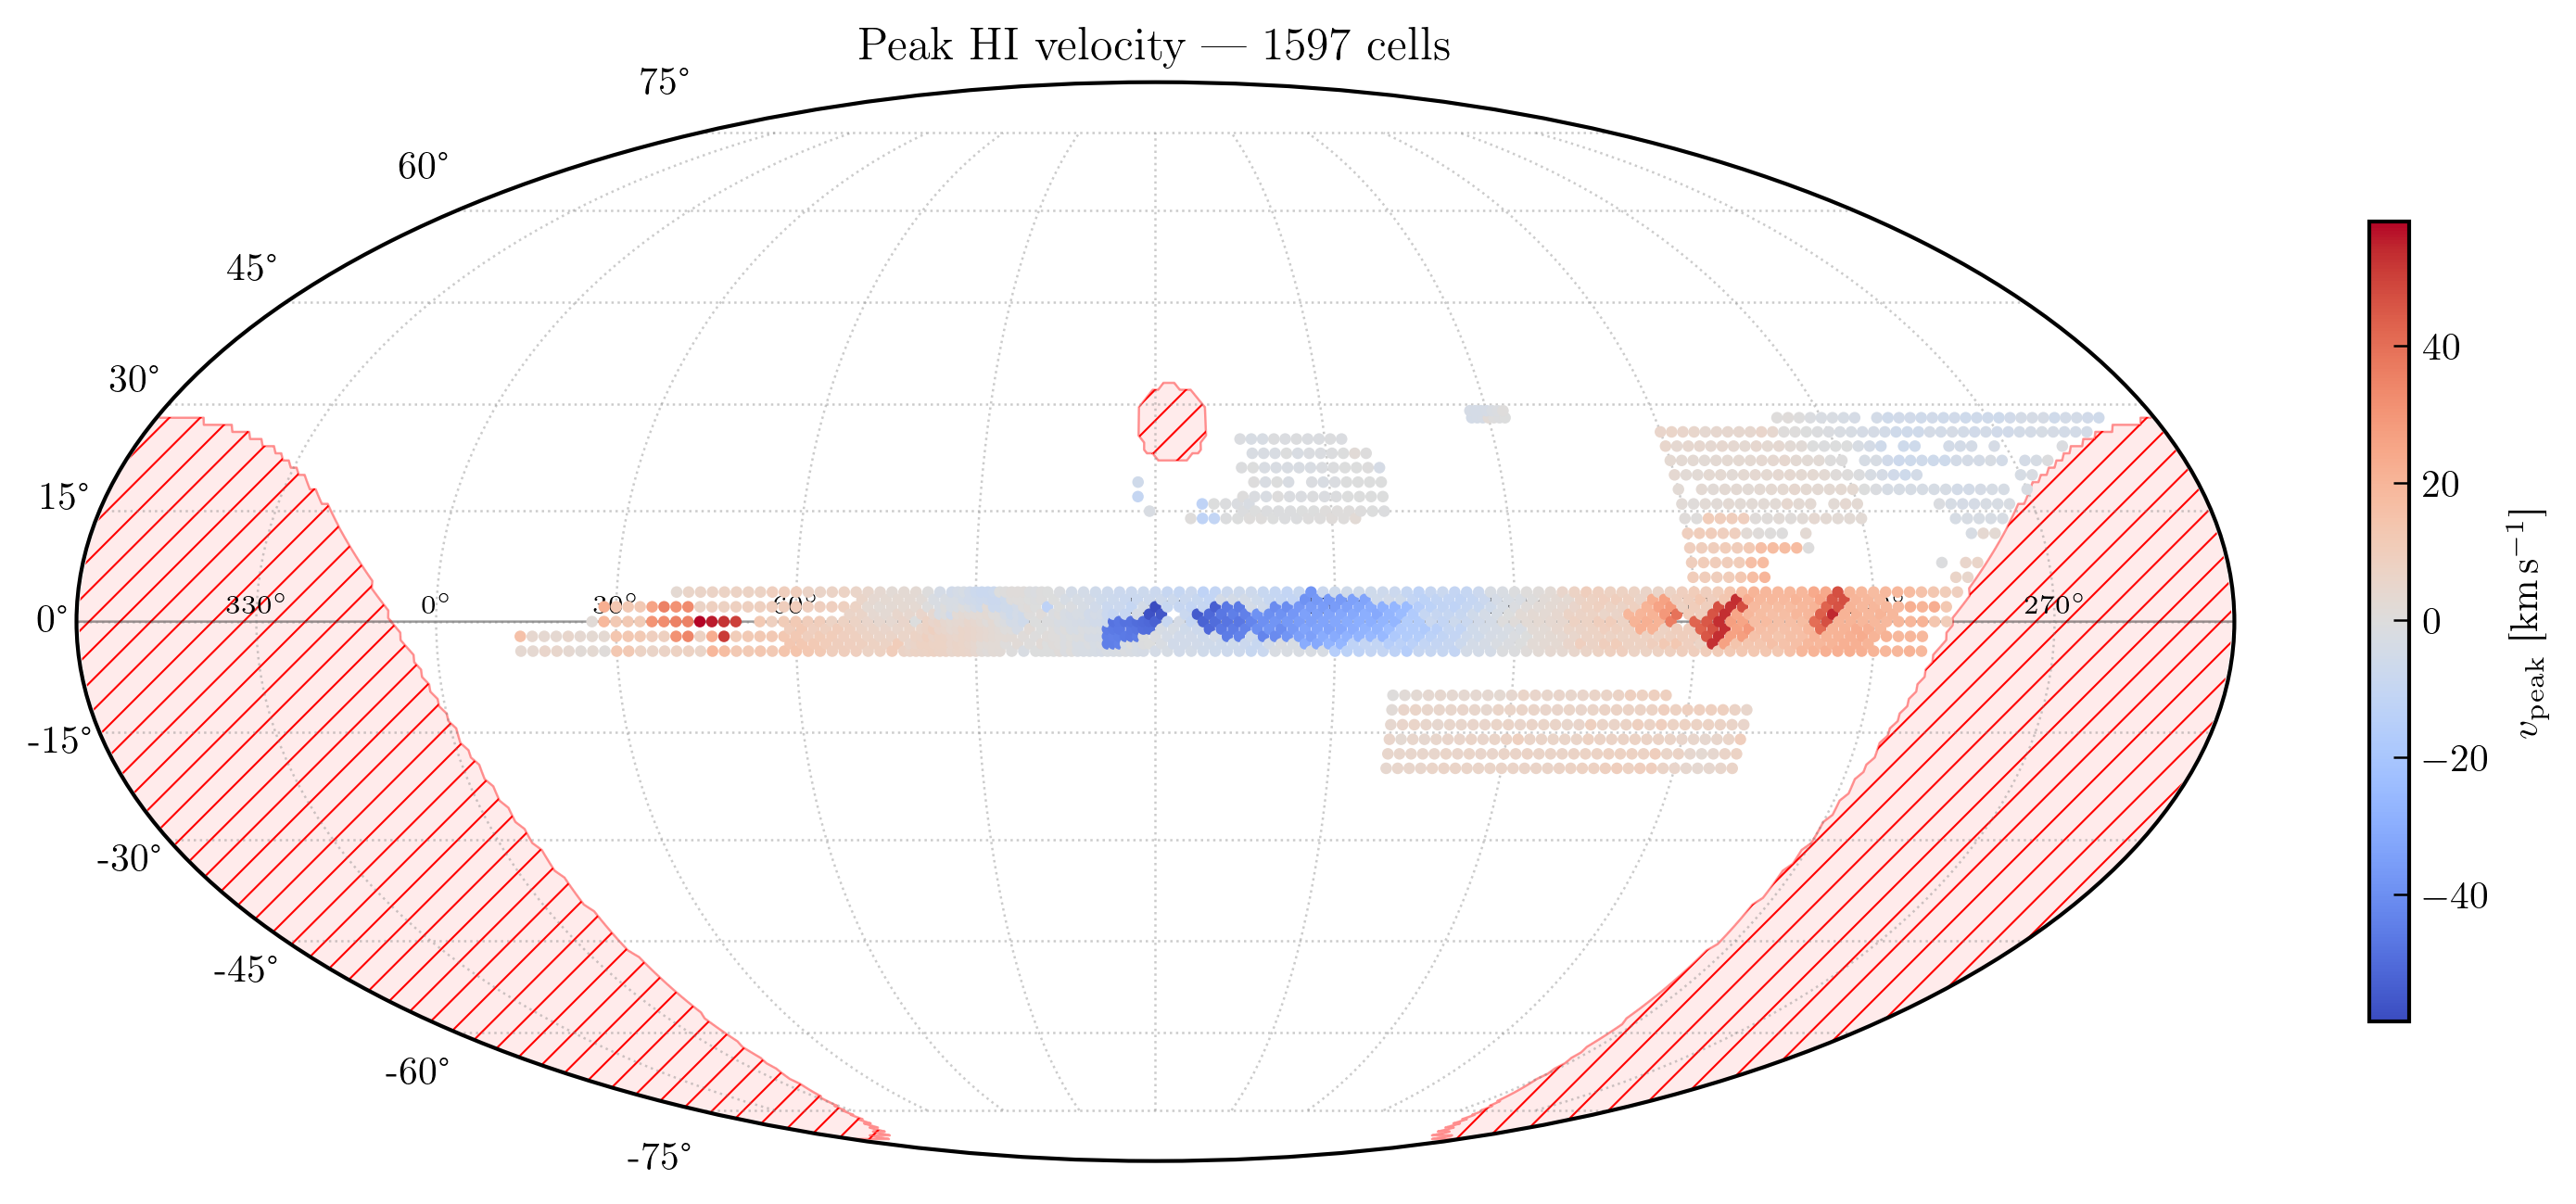

In [7]:
fig, ax = plot_survey_mollweide(
    gl[clean], gb[clean], peak_v[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$v_{\mathrm{peak}}$ [km\,s$^{-1}$]',
    cmap='coolwarm',
    marker_size=SS_FINE,
    title=f'Peak HI velocity --- {clean.sum()} cells',
)
plt.show()

## 7. Channel maps

Spatial maps of R at selected velocity slices.

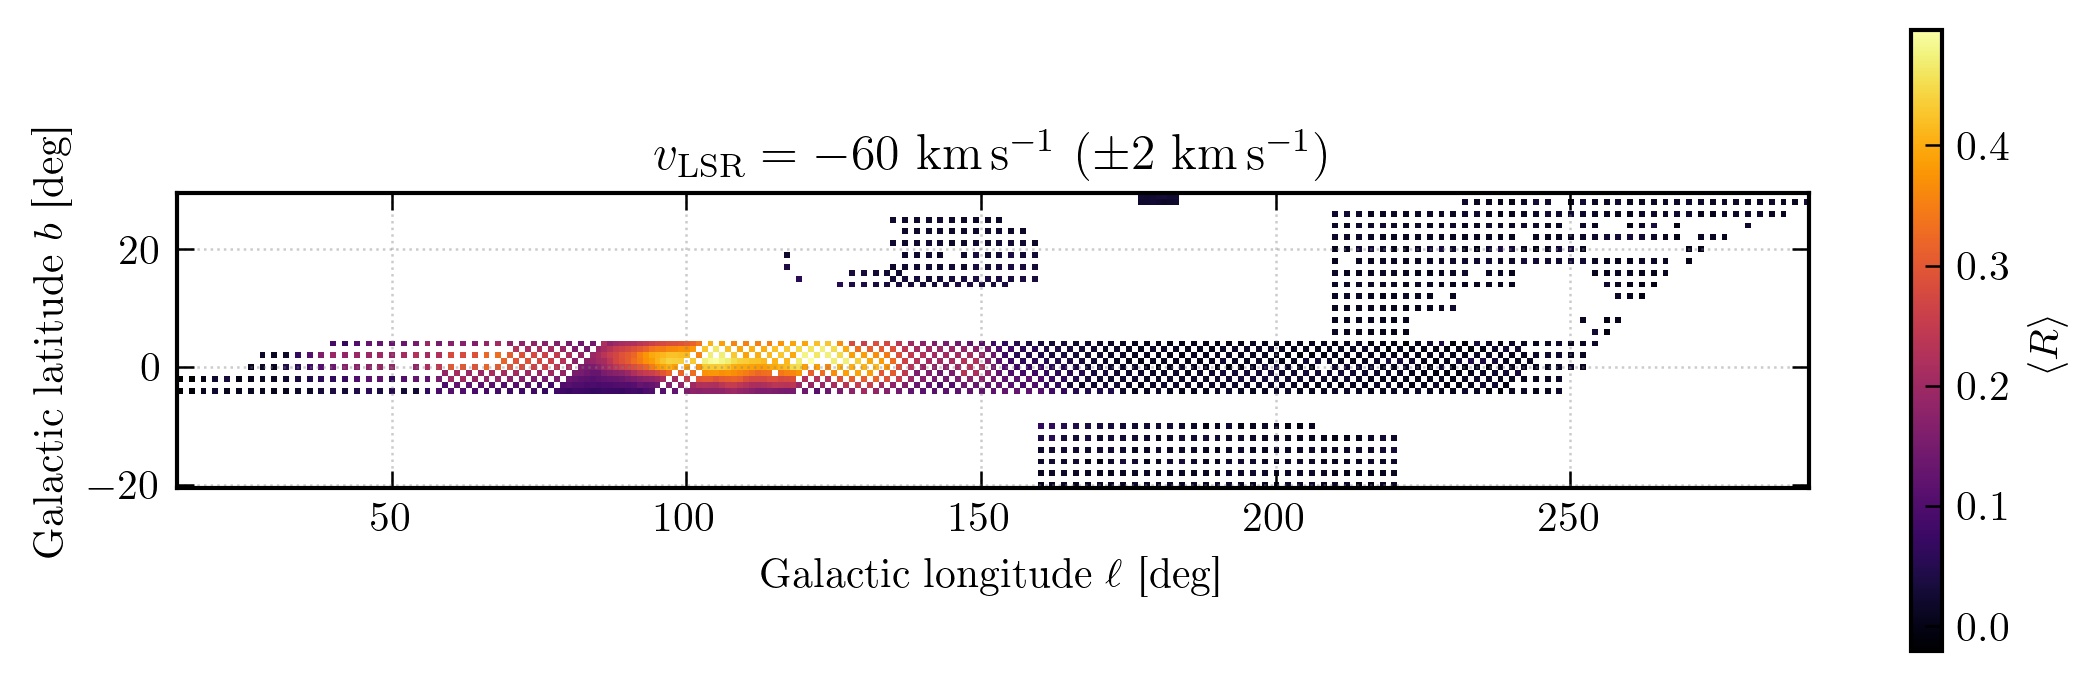

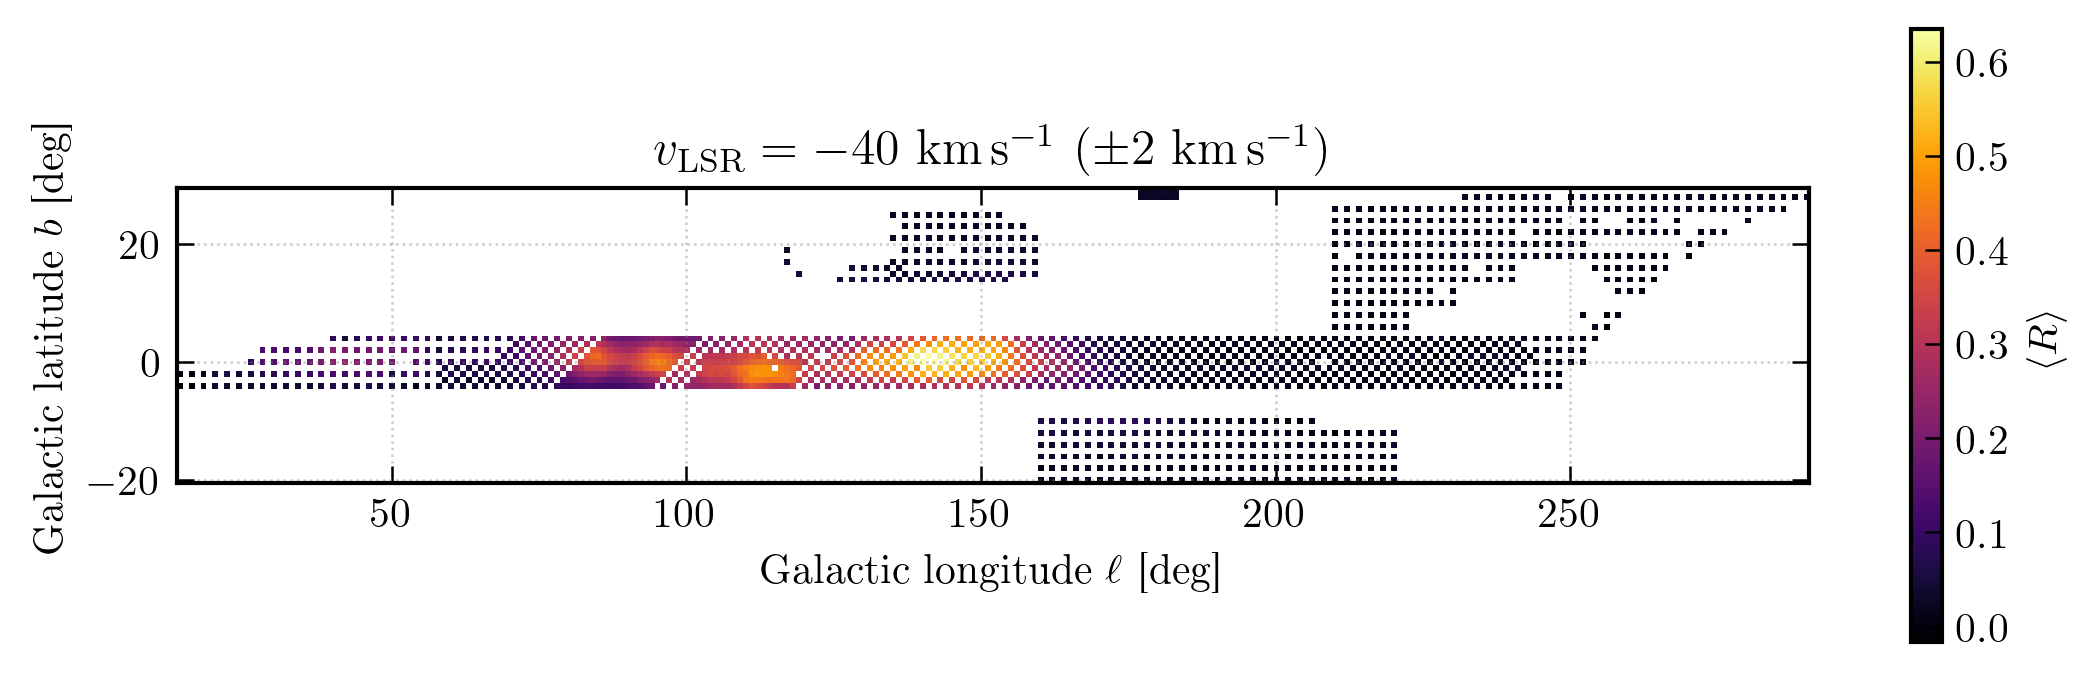

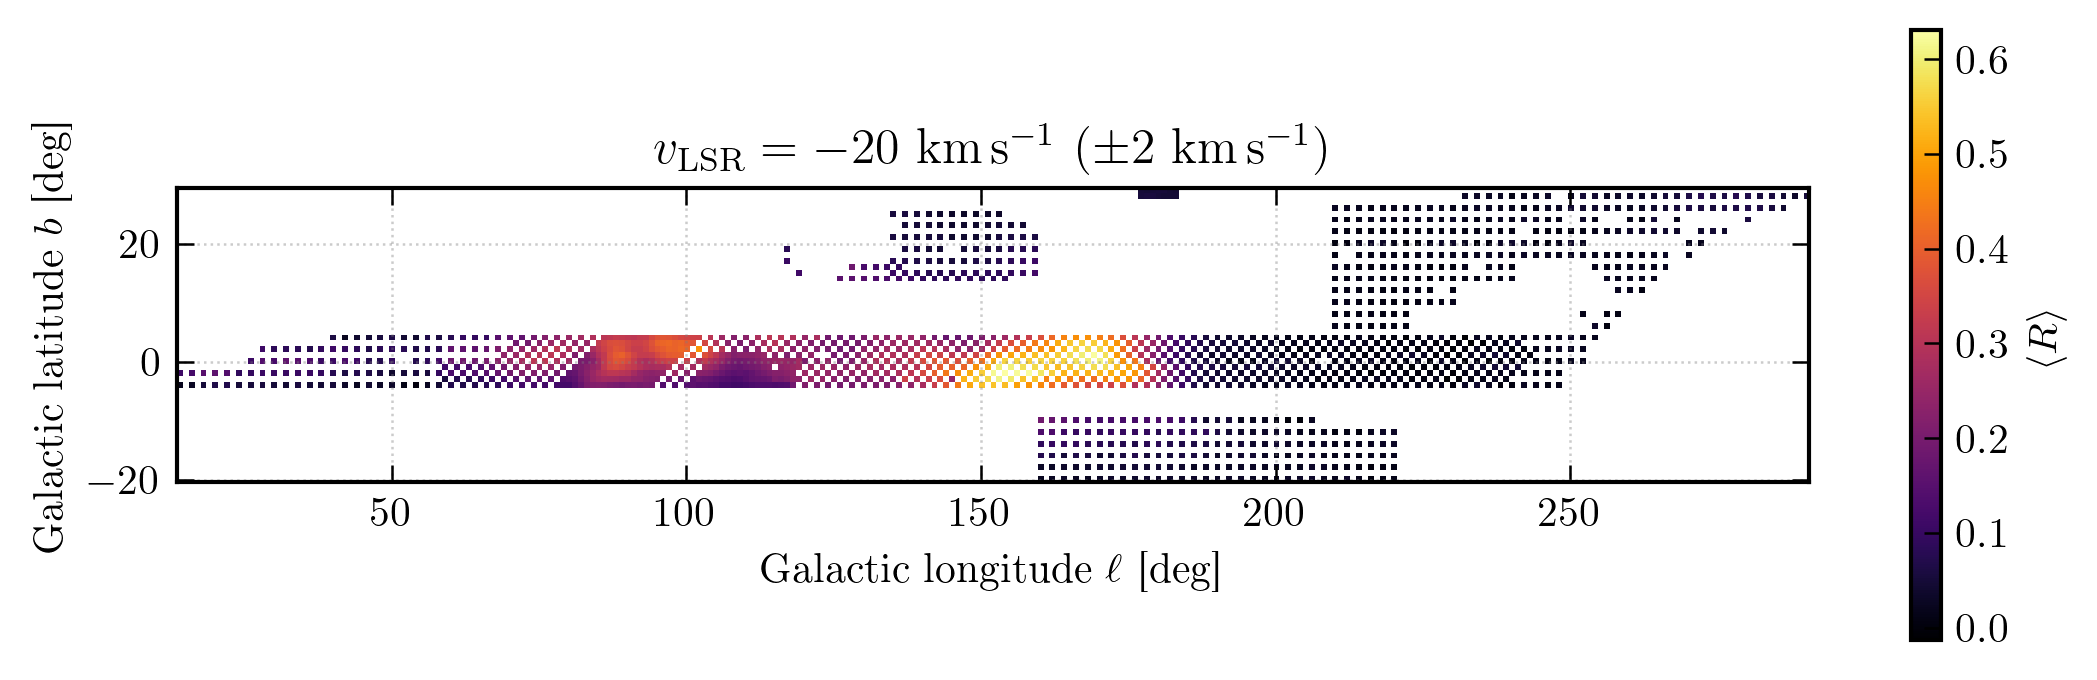

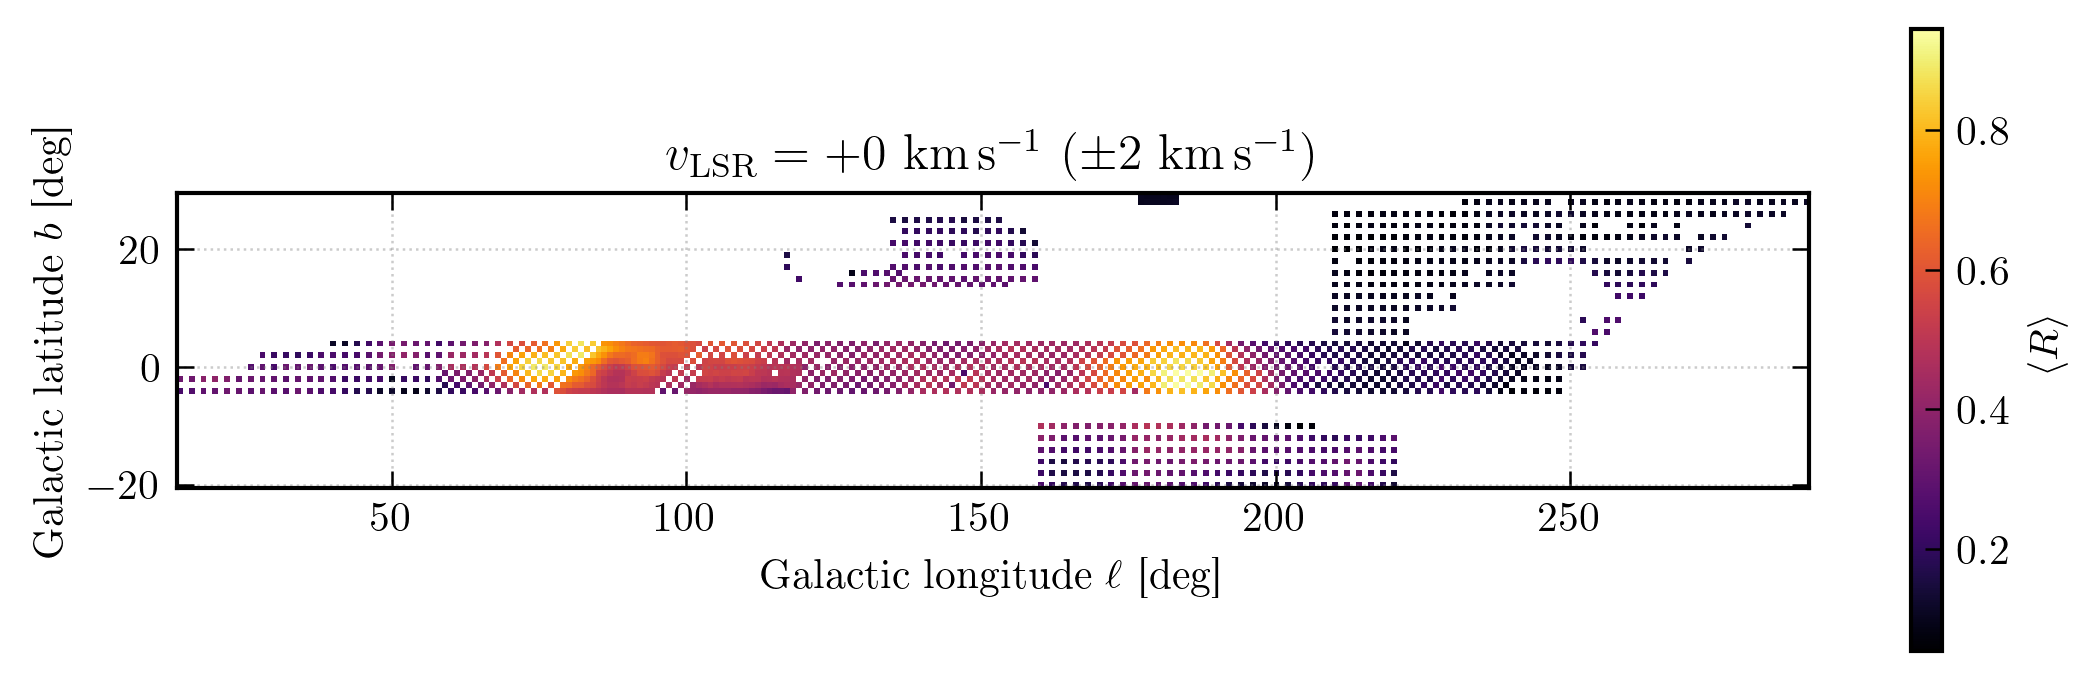

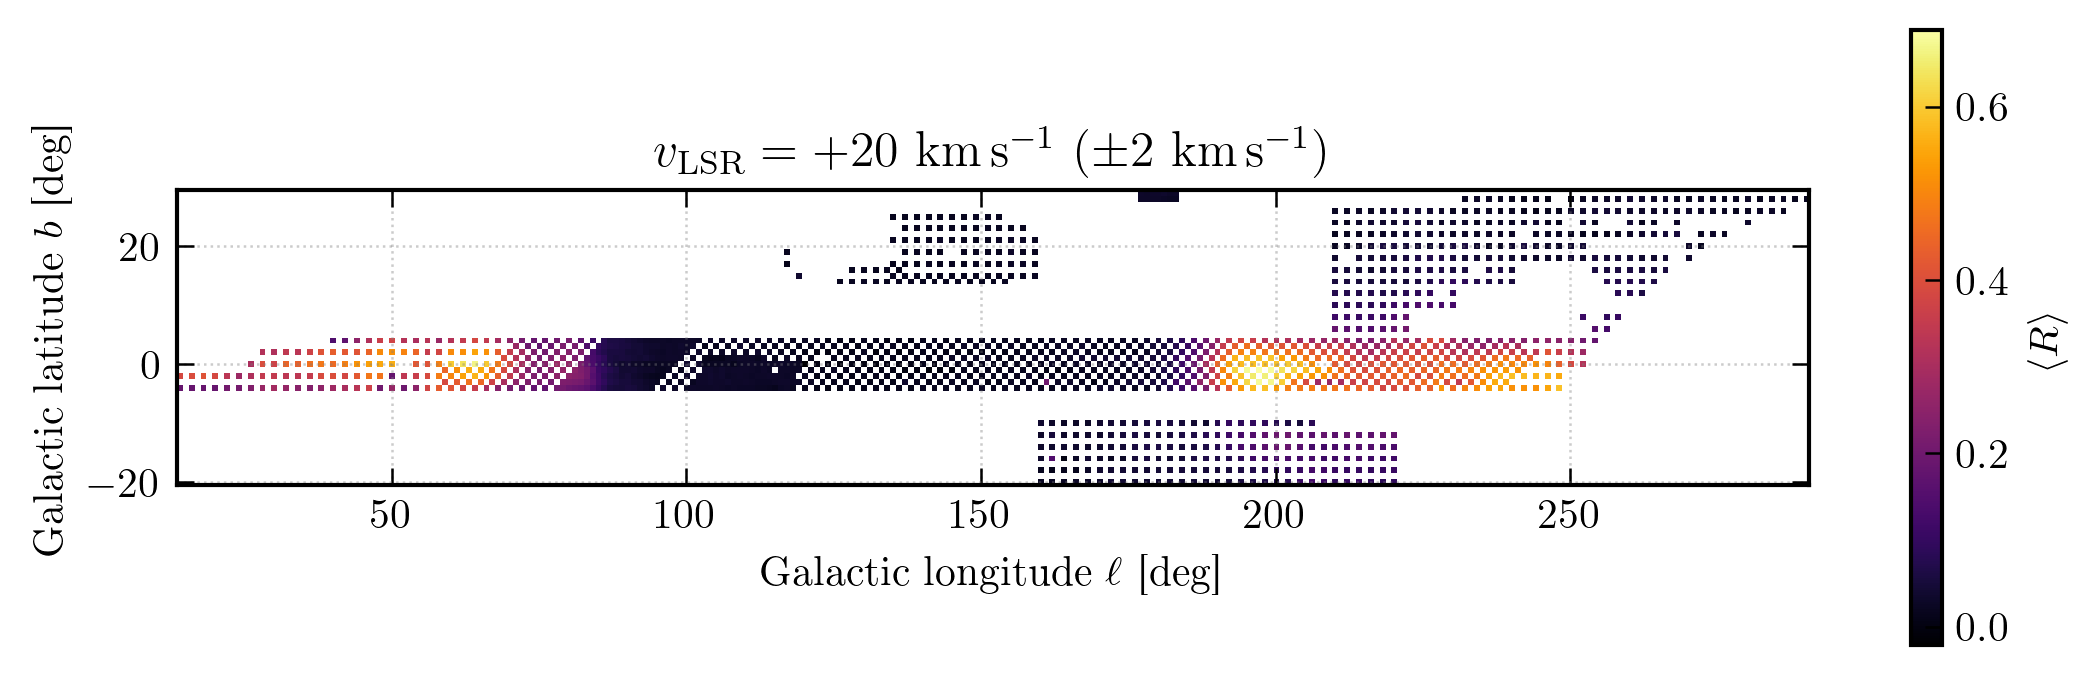

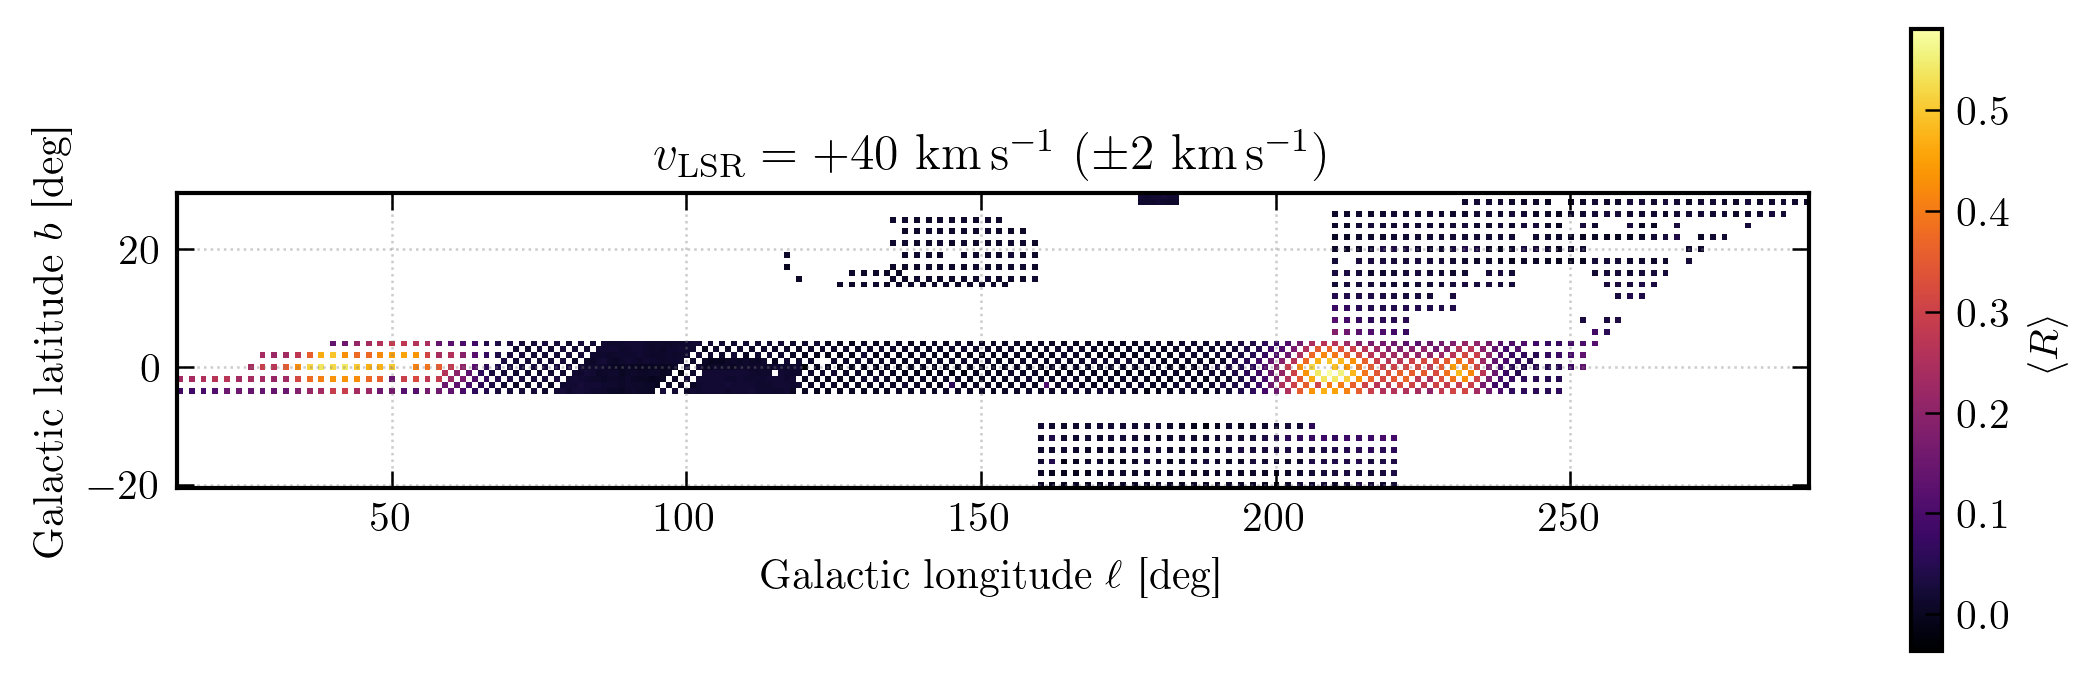

In [8]:
v_slices_kms = [-60, -40, -20, 0, 20, 40]

for v_target in v_slices_kms:
    # Average over a 5 km/s window centered on v_target
    v_window = 5.0
    ch_mask = (v_lsr >= v_target - v_window / 2) & (v_lsr <= v_target + v_window / 2)
    if ch_mask.sum() == 0:
        continue

    R_slice = np.nanmean(R_stack[clean][:, ch_mask], axis=1)

    fig, ax = plot_heatmap(
        gl[clean], gb[clean], R_slice,
        cbar_label=r'$\langle R \rangle$',
        cmap='inferno',
        title=rf'$v_{{\mathrm{{LSR}}}} = {v_target:+d}$ km\,s$^{{-1}}$ '
              rf'($\pm${v_window/2:.0f} km\,s$^{{-1}}$)',
    )
    plt.show()